In [ ]:
from Data_query.spark_config import *
from visualisation import *

import pytz
spark.catalog.setCurrentDatabase("solar_analytics")
warehouse_dir = spark.conf.get("spark.sql.warehouse.dir")
print(warehouse_dir)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/16 03:49:12 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).
25/09/16 03:49:15 WARN ConfigurationHelper: Option fs.s3a.connection.establish.timeout is too low (5,000 ms). Setting to 15,000 ms instead
Hive Session ID = fff466d3-9572-458f-ba0f-983050fc33dc


In [3]:
spark.sql("show tables").show(truncate=False)

+---------------+-------------------------------------------+-----------+
|namespace      |tableName                                  |isTemporary|
+---------------+-------------------------------------------+-----------+
|solar_analytics|ts                                         |false      |
|solar_analytics|sites                                      |false      |
|solar_analytics|circuits                                   |false      |
|solar_analytics|partition_lookup                           |false      |
|solar_analytics|meta_single_inverters                      |false      |
|solar_analytics|compliance_voltwatt                        |false      |
|solar_analytics|meta_single_inverters_wrong_capacity       |false      |
|solar_analytics|meta_single_inverters_wrong_capacity_up2_3c|false      |
|solar_analytics|compliance_voltvar                         |false      |
+---------------+-------------------------------------------+-----------+



In [5]:
spark.sql("select * from compliance_voltwatt where site_id = 305063631 and month=1").show(3)

+---------+----+-----+---+----------------------------+--------------------------+
|  site_id|year|month|day|noncompliance_voltwatt_count|noncompliance_voltwatt_sum|
+---------+----+-----+---+----------------------------+--------------------------+
|305063631|2025|    1| 20|                           0|                       0.0|
|305063631|2025|    1|  6|                           0|                       0.0|
|305063631|2025|    1| 14|                           0|                       0.0|
+---------+----+-----+---+----------------------------+--------------------------+
only showing top 3 rows


In [3]:
spark.sql("select * from meta_single_inverters_wrong_capacity_up2_3c where s_id = 'S3146'").show(3)

25/08/22 13:05:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+---------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+------+------------------------+---------------------------+-----------------+------------+------------+------------+--------------+-----+----+
|circuit_id|  site_id|device_id| device_type|circuit_polarity|circuit_type|is_pv|state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|manufacturer| model|ac_capacity_kw_exploaded|installed_after_18_dec_2021|     p99_power_kw|p01_power_kw|max_power_kw|min_power_kw|wrong_capacity| s_id|m_id|
+----------+---------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+------+---------

In [4]:
def get_max_P(V, Srated=1, v1=253, v2=260):
    if V is None:
        return None
    if V < v1:
        return Srated
    elif V > v2:
        return .2 * Srated
    else:
        m = (Srated - .2*Srated) / (v1 - v2)
        P = m * (V - v2) + .2*Srated
        return P
volt_watt_udf = udf(get_max_P, DoubleType())

In [5]:
first_write = True
for year in (2024, 2025):
    for month in range(1, 13):
        ts = spark.read.table("ts").filter(f"is_pv = True and year={year} and month = {month}")\
            .select("circuit_id", "t_stamp", "power", "voltage", "year", "month")
        ts = ts.withColumn('voltage', when((col('voltage') > 300) | (col('voltage') < 50), None).otherwise(col('voltage')))
        ts = ts.withColumn('P_kW', col('power') / 1000).drop('power')
        meta = spark.read.table("meta_single_inverters_wrong_capacity_up2_3c").select("circuit_id","site_id", "s_id", "ac_capacity_kw", 'circuit_polarity', 'wrong_capacity')\
                    .filter(col("wrong_capacity") == False).filter(col("ac_capacity_kw").isNotNull()).drop("wrong_capacity")\
                        .withColumnRenamed("circuit_id", "circuit_id_meta")
        df = ts.join(meta, ts.circuit_id == meta.circuit_id_meta, "inner").drop("circuit_id_meta")
        df = df.withColumn('P_kW', col('P_kW') * col('circuit_polarity')).drop('circuit_polarity')
        df = df.filter(col("voltage") > 253)
        df = df.groupBy("site_id", "s_id","t_stamp", "year", "month").agg(
            spark_sum("P_kW").alias("P_kW"),
            avg("voltage").alias("voltage"),
            avg("ac_capacity_kw").alias("ac_capacity_kw")
        )
        df = df.withColumn("max_P_volt_watt", volt_watt_udf(df.voltage, df.ac_capacity_kw) + 0.04*df.ac_capacity_kw)
        df = df.drop("ac_capacity_kw")
        df = df.withColumn("noncompliance_voltwatt", greatest(col('P_kW') - col('max_P_volt_watt'), lit(0)))
        df = df.withColumn("day", dayofmonth(col("t_stamp")))
        comp = df.groupBy('year','month',"day","site_id", "s_id")\
            .agg(spark_sum(when(col("noncompliance_voltwatt") > 0, 1).otherwise(0)).alias("noncompliance_voltwatt_count"), \
                spark_sum(col("noncompliance_voltwatt")).alias("noncompliance_voltwatt_sum"),
                spark_count(col("noncompliance_voltwatt")).alias("total_count"))\
            .sort("noncompliance_voltwatt_count", ascending=False)
        if first_write:
            comp.write.mode("overwrite").parquet(f"{warehouse_dir}/Compliance_results_SolA/compliance_voltwatt.parquet")
            first_write = False
        else:
            comp.write.mode("append").parquet(f"{warehouse_dir}/Compliance_results_SolA/compliance_voltwatt.parquet")

25/09/16 03:50:10 WARN S3ABlockOutputStream: Application invoked the Syncable API against stream writing to spark-warehouse/Compliance_results_SolA/compliance_voltwatt.parquet/_temporary/0/_temporary/attempt_202509160350098632116448651314031_0013_m_000000_15/part-00000-37ee64bf-5638-4ec6-98f1-d5112e95332b-c000.snappy.parquet. This is Unsupported
25/09/16 03:56:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [5]:
comp.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- site_id: long (nullable = true)
 |-- noncompliance_voltwatt_count: long (nullable = true)
 |-- noncompliance_voltwatt_sum: double (nullable = true)



In [6]:
spark.sql("drop table compliance_voltwatt")

DataFrame[]

In [7]:
spark.sql("""
CREATE EXTERNAL TABLE IF NOT EXISTS solar_analytics.compliance_voltwatt (
    site_id BIGINT,
    s_id STRING,
    year INT,
    month INT,
    day INT,
    noncompliance_voltwatt_count BIGINT,
    noncompliance_voltwatt_sum DOUBLE,
    total_count BIGINT
)
STORED AS PARQUET
LOCATION 's3a://project-ciccada/spark-warehouse/Compliance_results_SolA/compliance_voltwatt.parquet'
""")

DataFrame[]

In [4]:
spark.sql("select * from compliance_voltwatt limit 1").show()

+---------+----+-----+----------------------------+--------------------------+
|  site_id|year|month|noncompliance_voltwatt_count|noncompliance_voltwatt_sum|
+---------+----+-----+----------------------------+--------------------------+
|465008538|2024|   12|                        2175|         8030.307317214288|
+---------+----+-----+----------------------------+--------------------------+



In [8]:
comp = comp.toPandas()

In [18]:
comp.select("circuit_id").distinct().count()

9116

In [14]:
comp.head()

ERROR:root:KeyboardInterrupt while sending command.                 (0 + 8) / 8]
Traceback (most recent call last):
  File "/home/ubuntu/spark-4.0.0-bin-hadoop3/python/lib/py4j-0.10.9.9-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/spark-4.0.0-bin-hadoop3/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 707, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [11]:
spark.read.table("meta_single_inverters_wrong_capacity").filter("circuit_id = 454093").show()

+----------+----------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+-----------+------------------------+---------------------------+------------------+-----------------+--------------+
|circuit_id|   site_id|device_id| device_type|circuit_polarity|circuit_type|is_pv|state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|manufacturer|      model|ac_capacity_kw_exploaded|installed_after_18_dec_2021|      p99_power_kw|     max_power_kw|wrong_capacity|
+----------+----------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+-----------+------------------------+---------------------------+

In [8]:
dfp = df.filter("site_id = 465008538").toPandas()
dfp['t_stamp'] = dfp['t_stamp'].dt.tz_localize('UTC').dt.tz_convert(pytz.FixedOffset(10*60))  # Convert to UTC+110

In [13]:
dfp.head()

,circuit_id,t_stamp,voltage,year,month,P_kW,max_P_volt_watt,noncompliance_voltwatt
0,332548,2024-01-01 10:00:00+10:00,254.30,2024,1,5.748813,6.811429,0.000000
1,332548,2024-01-01 10:05:00+10:00,256.30,2024,1,7.140190,4.982857,2.157333
2,332548,2024-01-01 10:10:00+10:00,257.20,2024,1,6.928673,4.160000,2.768673
3,332548,2024-01-01 10:15:00+10:00,256.75,2024,1,6.520613,4.571429,1.949185
4,332548,2024-01-01 10:20:00+10:00,257.40,2024,1,7.419847,3.977143,3.442704


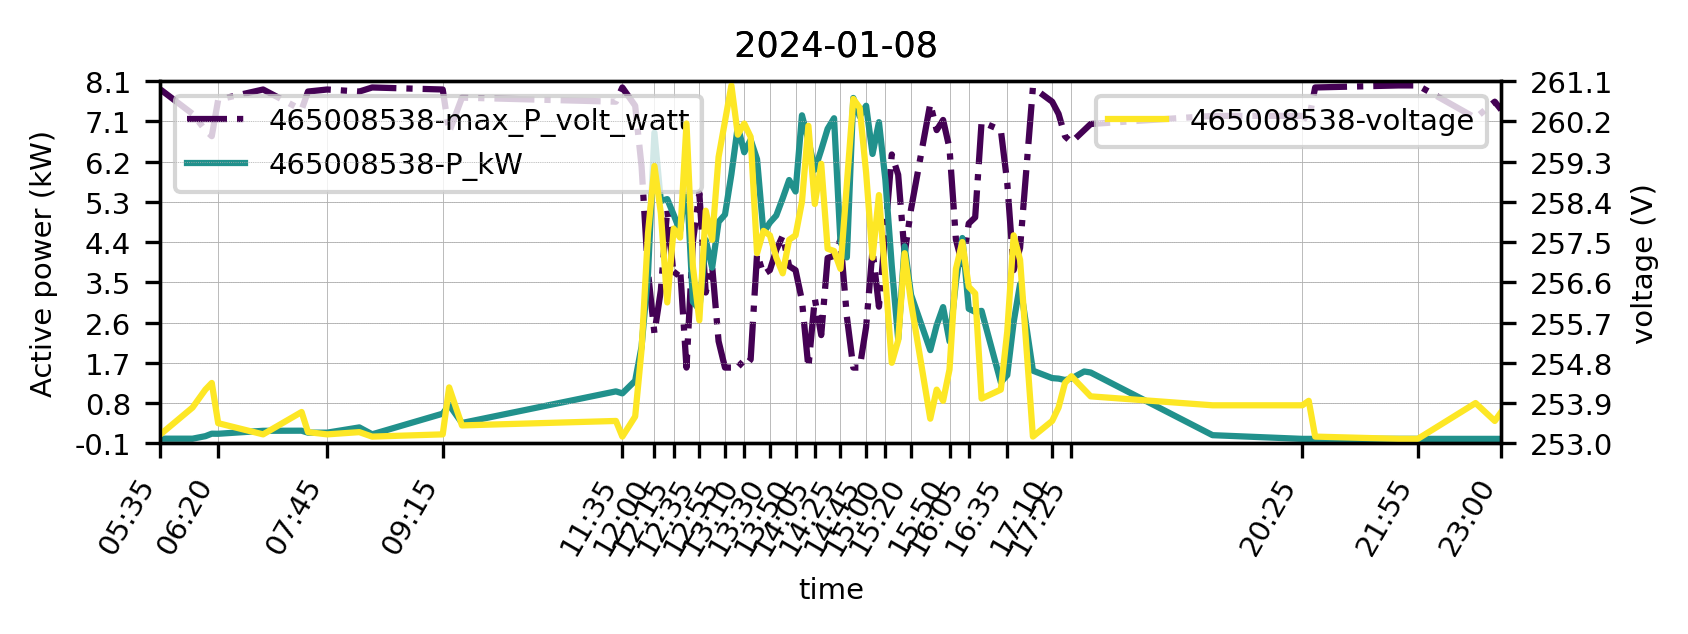

In [12]:
start_time = '2024-01-08 00:00:00+10:00'	 # In sydney local time
end_time =   '2024-01-09 00:00:00+10:00'	 # In sydney local time


num_ticks = 12*2+1
save_as = ''
x_label = 'time'
y_labels = ['Active power (kW)', 'Active power (kW)', 'voltage (V)']
plt_config = {'max_P_volt_watt': [0, 0, '-.', None, None], 'P_kW': [0, 0, '-', None, None],
'voltage': [0, 1, '-', None, None]}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, dfp, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='site_id', time_attr='t_stamp', color_nights=color_nights,cmap='viridis',
          figsize=[14/2.54,2],  same_scale=1, fontsize=7, fontname='DejaVu Sans', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M', 
           legend_loc=['upper left', 'upper right',  'upper right'], x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', legend_i=0, title_i=0, only1title=0)
a.do()

In [19]:
comp

[Row(year=2024, month=5, circuit_id=75410, noncompliance_voltwatt_count=8928, noncompliance_voltwatt_sum=16221.812447500002),
 Row(year=2024, month=7, circuit_id=74488, noncompliance_voltwatt_count=8928, noncompliance_voltwatt_sum=24211.34870309993),
 Row(year=2024, month=5, circuit_id=74488, noncompliance_voltwatt_count=8897, noncompliance_voltwatt_sum=23661.01576209999),
 Row(year=2024, month=3, circuit_id=75410, noncompliance_voltwatt_count=8868, noncompliance_voltwatt_sum=20333.038487300066),
 Row(year=2024, month=7, circuit_id=75410, noncompliance_voltwatt_count=8838, noncompliance_voltwatt_sum=16010.046740400052),
 Row(year=2024, month=1, circuit_id=75410, noncompliance_voltwatt_count=8676, noncompliance_voltwatt_sum=19520.54098532864),
 Row(year=2024, month=6, circuit_id=74488, noncompliance_voltwatt_count=8640, noncompliance_voltwatt_sum=21408.91059280007),
 Row(year=2024, month=9, circuit_id=622267, noncompliance_voltwatt_count=8639, noncompliance_voltwatt_sum=181266.760589299

In [ ]:
spark.sql("select * from circuits left join sites on circuits.site_id = sites.site_id").filter("circuit_id = 75410").show()

+---------+---------+----------+------------+----------------+------------+-----+---------+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+------+------------------------+---------------------------+
|  site_id|device_id|circuit_id| device_type|circuit_polarity|circuit_type|is_pv|  site_id|state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|manufacturer| model|ac_capacity_kw_exploaded|installed_after_18_dec_2021|
+---------+---------+----------+------------+----------------+------------+-----+---------+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+------+------------------------+---------------------------+
|965361792|    90636|     75410|Watt Watcher|               1| pv_site_net| true|965361792|

In [5]:
meta = spark.read.table("meta_single_inverters_wrong_capacity")
meta.filter("site_id = 1823687662").show()

+----------+----------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+--------------------+------------------------+---------------------------+------------+------------+--------------+
|circuit_id|   site_id|device_id| device_type|circuit_polarity|circuit_type|is_pv|state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|manufacturer|               model|ac_capacity_kw_exploaded|installed_after_18_dec_2021|p99_power_kw|max_power_kw|wrong_capacity|
+----------+----------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+--------------------+------------------------+-----------------------

In [27]:
spark.sql("select * from ts \
where circuit_id in (224045, 224043, 224044) and year = 2024 and month=1 and hour(t_stamp) > 1 order by t_stamp limit 10").show()

+----------+-------------------+---------+--------+---------------+-------------+-------------+----------------------+----------------------+------------------+------------------+------------------+----+-----+-----+
|circuit_id|            t_stamp|    power|  energy|energy_reactive|energy_import|energy_export|energy_reactive_import|energy_reactive_export|      power_factor|           voltage|           current|year|month|is_pv|
+----------+-------------------+---------+--------+---------------+-------------+-------------+----------------------+----------------------+------------------+------------------+------------------+----+-----+-----+
|    224044|2024-01-01 02:00:00|  4487.38|373.9483|        10.0753|     373.9483|          0.0|               10.0753|                   0.0|0.9992745997601507|            240.75|           18.3605|2024|    1| true|
|    224043|2024-01-01 02:00:00|4476.8367|373.0697|        10.1789|     373.0697|          0.0|               10.1789|                  

In [23]:
spark.sql("select * from sites \
where site_id = 1844098728").show()

+----------+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+--------------------+------------------------+---------------------------+
|   site_id|state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|manufacturer|               model|ac_capacity_kw_exploaded|installed_after_18_dec_2021|
+----------+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+--------------------+------------------------+---------------------------+
|1844098728|  NSW|  2155.0|   150.95| -33.705|Endeavour|         10.23|          10.0|           NULL|      2020-01-10|           1.0|     2020-01-09|         SMA|Sunny Tripower100...|                    10.0|                      false|
+----------+-----+--------+---------+--------+--

In [9]:
spark.sql("select site_id from meta_single_inverters_wrong_capacity \
group by site_id  \
having count(circuit_id) > 1 \
          and cast(avg(ac_capacity_kw) as integer) = cast(min(ac_capacity_kw) as integer)").show()

+----------+
|   site_id|
+----------+
|1896837313|
|1844098728|
| 766851425|
|1621355227|
| 643628097|
|1823687662|
|1372056504|
| 933307265|
| 998806724|
|1513554119|
| 461916229|
|1232342295|
|1680456172|
|1454659752|
|1926547054|
|1882641335|
|1232894553|
| 646736185|
|1272488866|
|1179914101|
+----------+
only showing top 20 rows


In [4]:
df = spark.read.table("compliance_voltwatt")

In [5]:
dfp = df.toPandas()

In [ ]:
dfp.query(f"year==2024 and month==1")

(2298,)

In [3]:
spark.sql("with data as (\
select site_id, t, avg(P*circuit_polarity) as P \
from \
 (select circuit_id, t_stamp as t, power/1000 as P \
 from ts \
 where year = 2024 \
 and month = 1 \
 and is_pv = True \
) as ts inner join \
(select site_id, circuit_id, circuit_polarity from \
meta_single_inverters_wrong_capacity_up2_3c) as m on ts.circuit_id = m.circuit_id \
group by site_id, t), \
negative_powers as (select site_id, percentile_approx(P, .01) as p01, min(P) as P_min from data \
          group by site_id) \
          select count(site_id) as count_sites from negative_powers where P_min < -1").show(20, truncate=False)

+-----------+
|count_sites|
+-----------+
|320        |
+-----------+

